In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. EDA

## 1.1 Đọc dữ liệu

In [2]:
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

## 1.2 Xem tổng quan dataset

In [3]:
train_df.shape, test_df.shape

((7352, 563), (2947, 563))

In [4]:
train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [6]:
train_df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


## 1.3 Missing Values

In [7]:
train_df.isna().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

In [8]:
train_df.isna().sum().sum()

np.int64(0)

In [9]:
test_df.isna().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

In [10]:
test_df.isna().sum().sum()

np.int64(0)

## 1.4 Duplicate check

In [11]:
train_df.duplicated().sum()

np.int64(0)

In [12]:
test_df.duplicated().sum()

np.int64(0)

## 1.5 Class distribution

In [13]:
train_df['Activity'].value_counts(normalize=True)

Activity
LAYING                0.191376
STANDING              0.186888
SITTING               0.174918
WALKING               0.166757
WALKING_UPSTAIRS      0.145947
WALKING_DOWNSTAIRS    0.134113
Name: proportion, dtype: float64

In [14]:
test_df['Activity'].value_counts(normalize=True)

Activity
LAYING                0.182219
STANDING              0.180523
WALKING               0.168307
SITTING               0.166610
WALKING_UPSTAIRS      0.159824
WALKING_DOWNSTAIRS    0.142518
Name: proportion, dtype: float64

## 1.6 Outlier detection

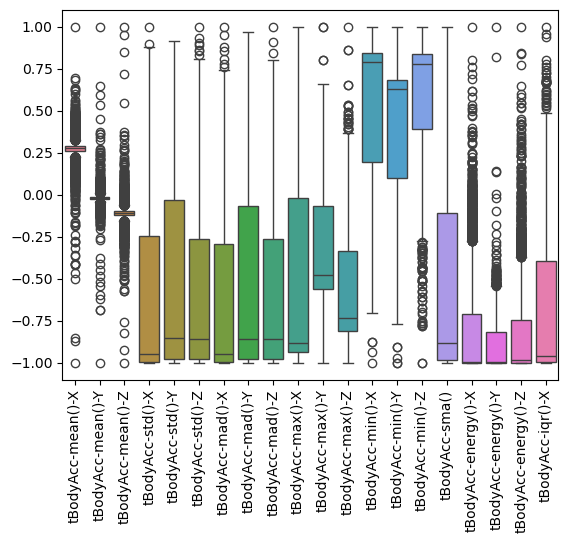

In [15]:
sns.boxplot(data=train_df[train_df.columns[:20]], orient='v')
plt.xticks(rotation=90)
plt.show()

```text
               Dưới này là Outliers
                     o  o
                     │
             ┌───────┴───────┐ ◄─── Mốc Max (bình thường)
             │               │
             │   ┌───────┐   │ ◄─── Cạnh trên của hộp chính là Q3 (75%)
             │   │       │   │
             │   ├───────┤   │ ◄─── Đường vạch ngang giữa hộp là Q2 (Median - 50%)
             │   │       │   │
             │   └───────┘   │ ◄─── Cạnh dưới của hộp chính là Q1 (25%)
             └───────┬───────┘ ◄─── Mốc Min (bình thường)
                     │
                     o         ◄─── Trên này cũng là Outliers
```

C:\Users\HUNG PC\AppData\Local\Temp\ipykernel_5792\1525548445.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HUNG PC\AppData\Local\Temp\ipykernel_5792\1525548445.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HUNG PC\AppData\Local\Temp\ipykernel_5792\1525548445.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HUNG PC\AppData\Local\Temp\ipykernel_5792\1525548445.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

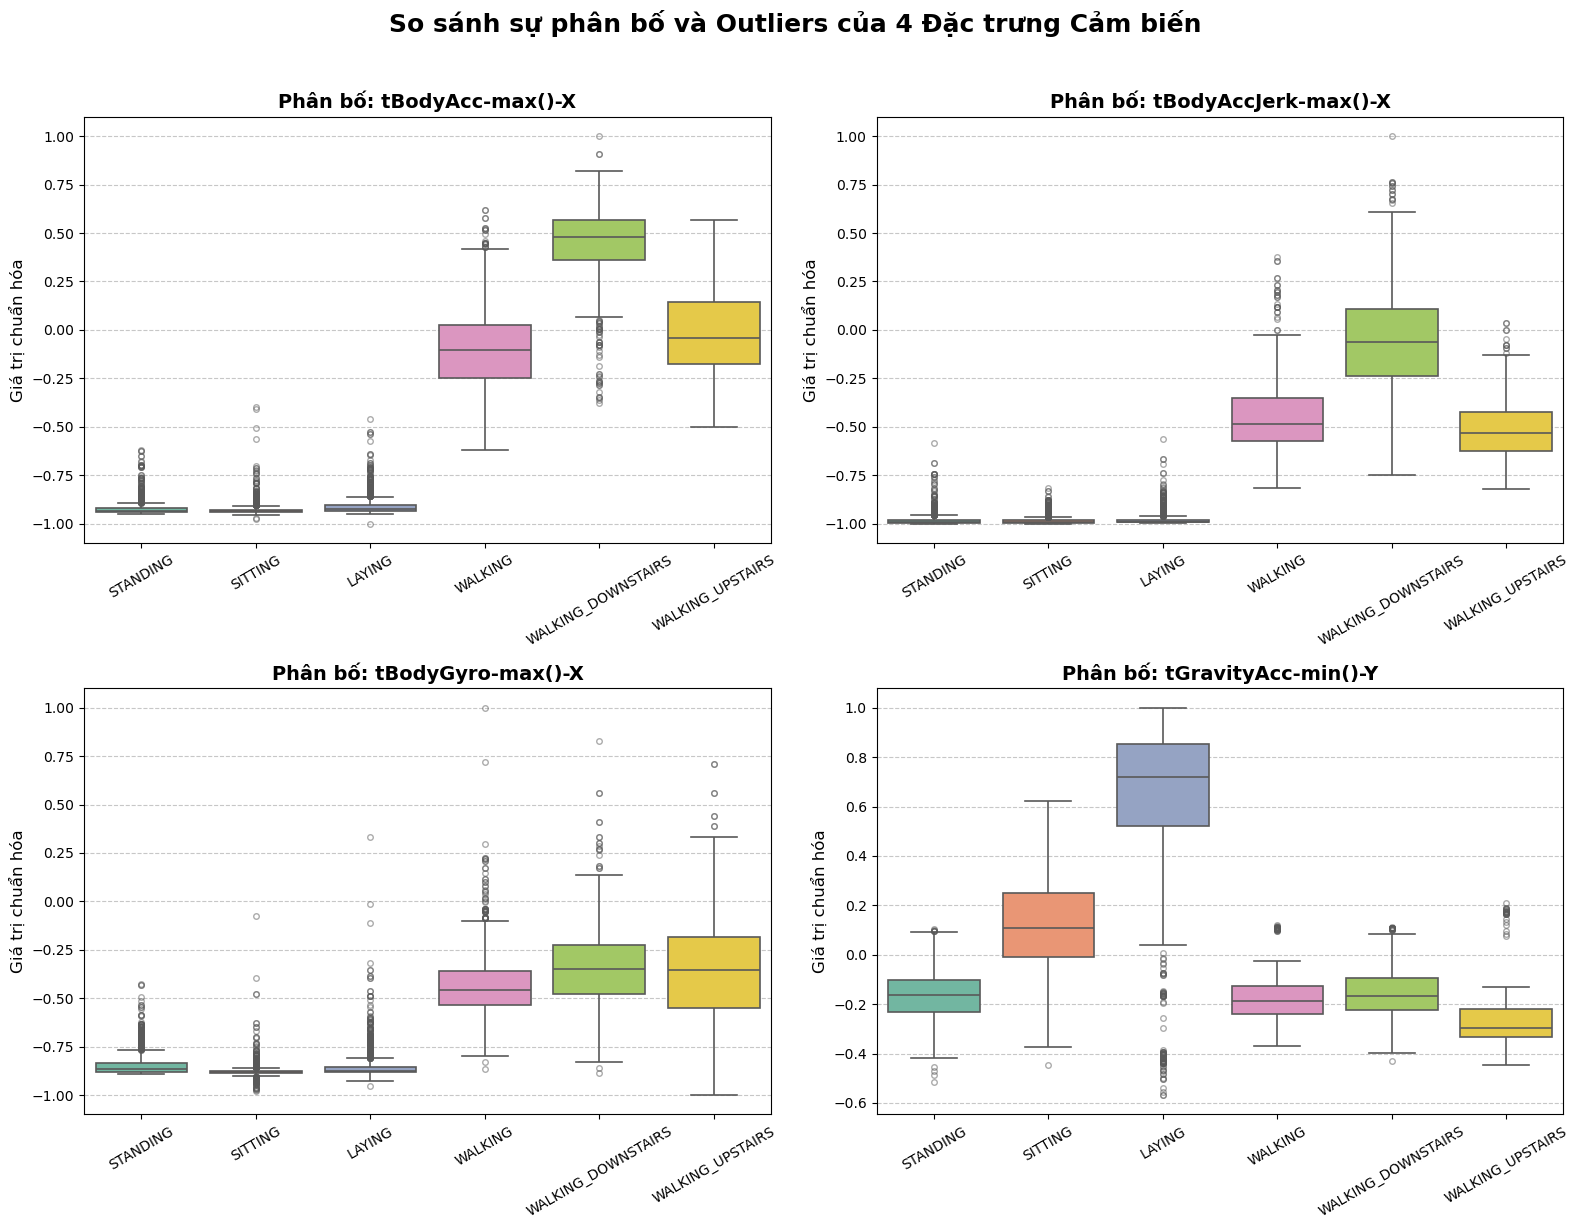

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Khai báo 4 features cốt lõi
selected_features = [
    'tBodyAcc-max()-X',       # Gia tốc cơ thể tối đa - Trục X
    'tBodyAccJerk-max()-X',   # Độ giật gia tốc tối đa - Trục X
    'tBodyGyro-max()-X',      # Vận tốc góc tối đa - Trục X
    'tGravityAcc-min()-Y'     # Gia tốc trọng trường tối thiểu - Trục Y
]

# 2. Khởi tạo một khung hình (Figure) gồm 4 đồ thị con (Subplots) kích thước 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# Làm phẳng mảng axes để dễ dàng dùng vòng lặp
axes = axes.flatten()

# 3. Vòng lặp để vẽ từng Boxplot lên từng ô đồ thị con
for i, feature in enumerate(selected_features):
    sns.boxplot(
        data=train_df, 
        x='Activity', 
        y=feature, 
        ax=axes[i], 
        palette='Set2', 
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, color='black') # Outliers
    )
    
    # Trang trí cho từng đồ thị con
    axes[i].set_title(f'Phân bố: {feature}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Ẩn chữ 'Activity' ở trục X cho đỡ rối
    axes[i].set_ylabel('Giá trị chuẩn hóa', fontsize=12)
    axes[i].tick_params(axis='x', rotation=30) # Xoay nhãn để không bị đè lên nhau
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Tinh chỉnh bố cục tổng thể và hiển thị
plt.suptitle('So sánh sự phân bố và Outliers của 4 Đặc trưng Cảm biến', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. DataPreparation

## 2.1 Data Encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(train_df['Activity'])
y_test = le.transform(test_df['Activity'])

In [18]:

for i, label in enumerate(le.classes_):
    print(f"{i}: {label}") 

0: LAYING
1: SITTING
2: STANDING
3: WALKING
4: WALKING_DOWNSTAIRS
5: WALKING_UPSTAIRS


In [19]:
y_train, y_test

(array([2, 2, 2, ..., 5, 5, 5], shape=(7352,)),
 array([2, 2, 2, ..., 5, 5, 5], shape=(2947,)))

In [20]:
X_train = train_df.drop(columns=['Activity', 'subject'])
X_test = test_df.drop(columns=['Activity', 'subject'])

In [21]:
X_train.shape, X_test.shape

((7352, 561), (2947, 561))

## 2.2 Data Scaling

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
X_train.shape, X_test.shape

((7352, 561), (2947, 561))

In [24]:
X_train.mean(), X_train.std()

(np.float64(1.1804271735699034e-17), np.float64(1.0))

In [25]:
X_test.mean(), X_test.std()   

(np.float64(-0.011128413622992503), np.float64(0.9289333099557896))

## 2.3 Cắt giảm chiều dữ liệu

In [26]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo Random Forest để đánh giá đặc trưng
# Thiết lập n_jobs=-1 để tận dụng tối đa số luồng CPU, giúp chạy nhanh hơn
rf_evaluator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Fit mô hình trên tập train đã chuẩn hóa
rf_evaluator.fit(X_train, y_train)

# 3. Sử dụng SelectFromModel
# Thuật toán sẽ tự động tính toán ngưỡng (thường là giá trị trung bình độ quan trọng)
# và giữ lại các biến vượt qua ngưỡng này.
selector = SelectFromModel(rf_evaluator, prefit=True)

# 4. Thực hiện transform để sinh ra tập dữ liệu mới đã được làm gọn
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

print(f"Số lượng đặc trưng quan trọng được giữ lại: {X_train.shape[1]}")

Số lượng đặc trưng quan trọng được giữ lại: 121


C:\Users\HUNG PC\AppData\Local\Temp\ipykernel_19268\2571345434.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances_df.head(20), x='Importance', y='Feature', palette='viridis')


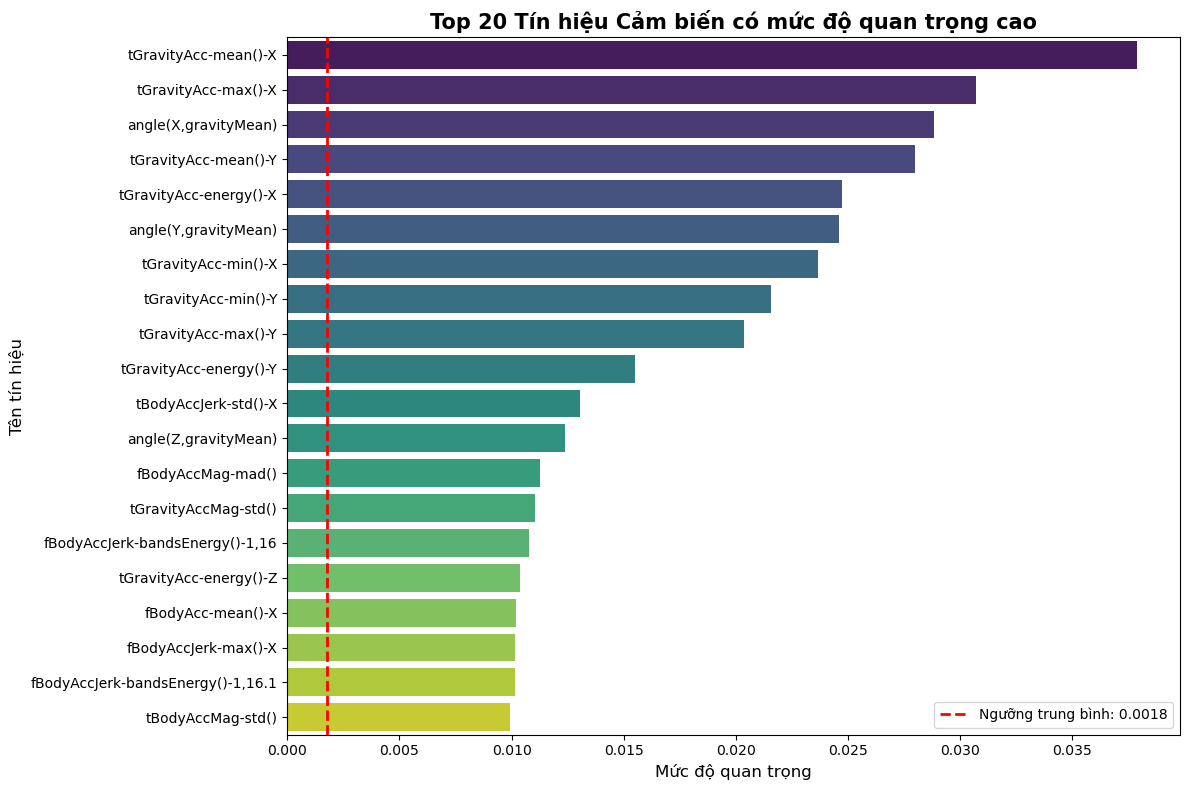

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lấy mảng điểm số độ quan trọng từ mô hình Random Forest
importances = rf_evaluator.feature_importances_

# Xác định ngưỡng (trung bình độ quan trọng)
threshold = importances.mean()

# Lấy tên cái features
feature_names = train_df.drop(columns=['Activity', 'subject']).columns 

# Tạo DataFrame để ghép cặp tên tín hiệu với điểm số, sau đó sắp xếp giảm dần
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ Top 20 tín hiệu quan trọng nhất
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances_df.head(20), x='Importance', y='Feature', palette='viridis')

plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Ngưỡng trung bình: {threshold:.4f}')

plt.title('Top 20 Tín hiệu Cảm biến có mức độ quan trọng cao', fontsize=15, fontweight='bold')
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Tên tín hiệu', fontsize=12)
plt.legend()

# Chỉnh giao diện cho gọn gàng
plt.tight_layout()
plt.show()

# 3. Model Training

## 3.1 Logistic Regression

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Thiết lập kiểm định chéo 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Khởi tạo Logistic Regression cơ sở
lr_base = LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)

# Định nghĩa lưới tham số cho Logistic Regression
lr_param_grid = {
    "C": [0.1, 0.5, 1, 2, 5],
    "solver": ["lbfgs", "saga"],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"],
}

# Thiết lập GridSearchCV để tìm kiếm tham số tốt nhất
lr_search = GridSearchCV(
    lr_base,
    lr_param_grid,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy",
    refit=True,
)

# Thực hiện tìm kiếm tham số tốt nhất trên tập train
lr_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất từ GridSearchCV
lr_model = lr_search.best_estimator_

# Tính accuracy
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Logistic Regression Best Params:", lr_search.best_params_)

Logistic Regression Accuracy: 0.9379029521547336
Logistic Regression Best Params: {'C': 5, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}


## 3.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Khởi tạo Random Forest cơ sở
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Định nghĩa lưới tham số cho Random Forest
rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

# Thiết lập RandomizedSearchCV để tìm kiếm tham số tốt nhất
rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_dist,
    n_iter=20, # Lấy 20 kết hợp tham số ngẫu nhiên để thử nghiệm
    cv=cv,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    refit=True,
)

# Thực hiện tìm kiếm tham số tốt nhất trên tập train 
rf_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất từ RandomizedSearchCV
rf_model = rf_search.best_estimator_

# Tính accuracy
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)
print("Random Forest Best Params:", rf_search.best_params_)

Random Forest Accuracy: 0.9134713267729895
Random Forest Best Params: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}


## 3.3 SVM

In [64]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Khởi tạo SVM cơ sở
svm_base = SVC(random_state=42)

# Định nghĩa lưới tham số cho SVM, bao gồm cả kernel tuyến tính và RBF
svm_param_grid = [
    {"kernel": ["linear"], "C": [0.5, 1, 2, 5]},
    {"kernel": ["rbf"], "C": [0.5, 1, 2, 5], "gamma": ["scale", 0.01, 0.1]},
]

# Thiết lập GridSearchCV để tìm kiếm tham số tốt nhất cho SVM
svm_search = GridSearchCV(
    svm_base,
    svm_param_grid,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy",
    refit=True,
)

# Thực hiện tìm kiếm tham số tốt nhất trên tập train
svm_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất từ GridSearchCV
svm_model = svm_search.best_estimator_

# Tính accuracy
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)
print("SVM Best Params:", svm_search.best_params_)

SVM Accuracy: 0.9304377332880895
SVM Best Params: {'C': 5, 'gamma': 0.01, 'kernel': 'rbf'}


# 4. Model Evaluation

## 4.1 Logistic Regression

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       537
           1       0.92      0.85      0.88       491
           2       0.87      0.93      0.90       532
           3       0.94      0.99      0.96       496
           4       1.00      0.92      0.96       420
           5       0.92      0.94      0.93       471

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



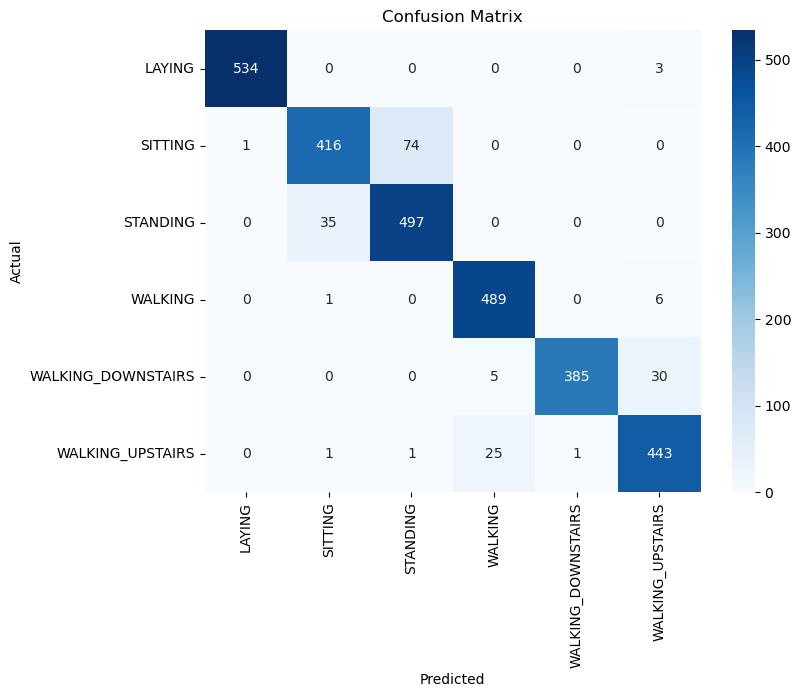

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues', 
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()



In [67]:
train_acc_lr = lr_model.score(X_train, y_train)

test_acc_lr = lr_model.score(X_test, y_test)

print("Train Accuracy (LR):", train_acc_lr)
print("Test Accuracy (LR):", test_acc_lr)

Train Accuracy (LR): 0.9779651795429815
Test Accuracy (LR): 0.9379029521547336


## 4.2 Random Forest

In [68]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.89      0.85      0.87       491
           2       0.87      0.91      0.89       532
           3       0.88      0.97      0.92       496
           4       0.97      0.83      0.90       420
           5       0.88      0.90      0.89       471

    accuracy                           0.91      2947
   macro avg       0.92      0.91      0.91      2947
weighted avg       0.92      0.91      0.91      2947



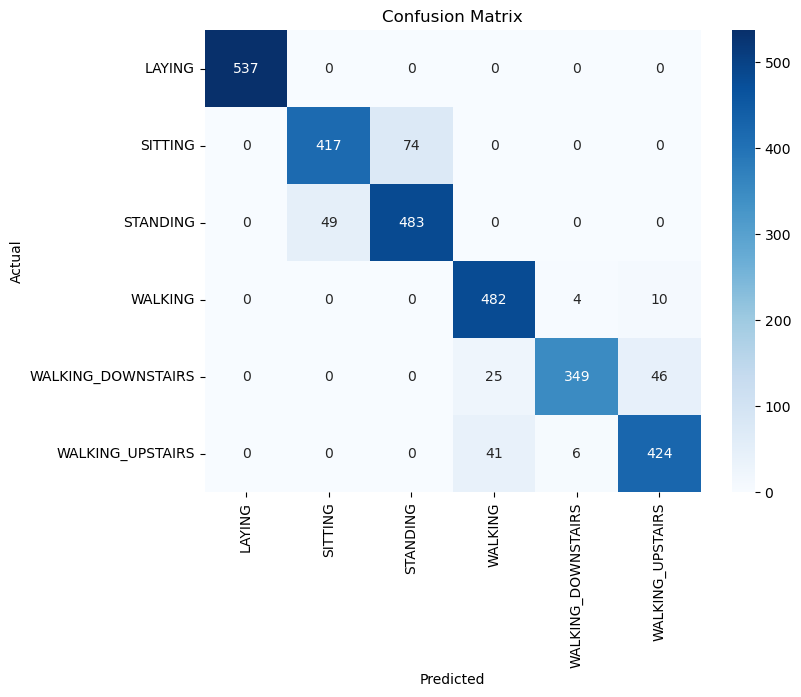

In [69]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [70]:
train_acc_rf = rf_model.score(X_train, y_train)
test_acc_rf = rf_model.score(X_test, y_test)

print("Train Accuracy (RF):", train_acc_rf)
print("Test Accuracy (RF):", test_acc_rf)

Train Accuracy (RF): 1.0
Test Accuracy (RF): 0.9134713267729895


## 4.3 SVM

In [71]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.92      0.82      0.87       491
           2       0.86      0.94      0.89       532
           3       0.93      0.99      0.96       496
           4       0.98      0.88      0.93       420
           5       0.92      0.93      0.92       471

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



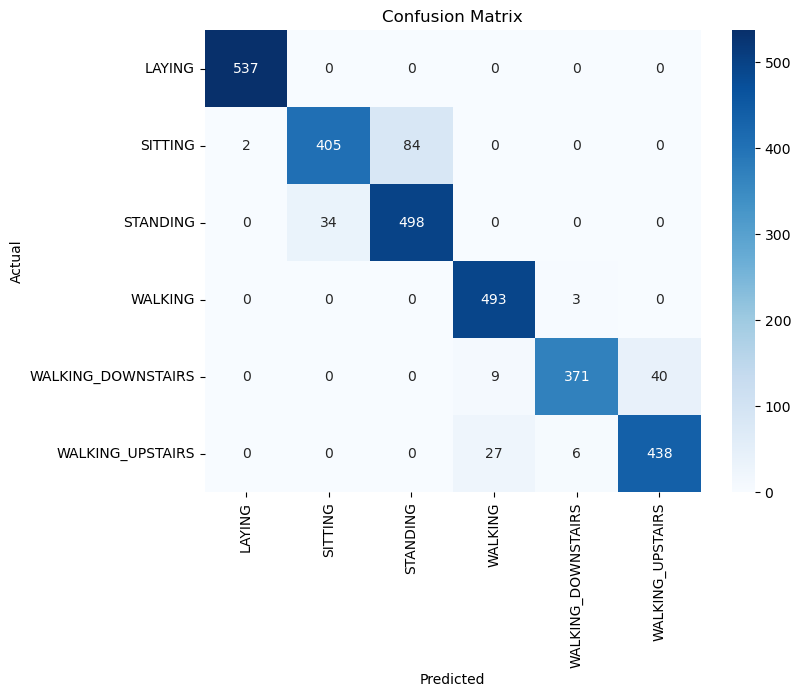

In [72]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [73]:
train_acc_svm = svm_model.score(X_train, y_train)
test_acc_svm = svm_model.score(X_test, y_test) 

print("Train Accuracy (SVM):", train_acc_svm)
print("Test Accuracy (SVM):", test_acc_svm)

Train Accuracy (SVM): 0.9817736670293797
Test Accuracy (SVM): 0.9304377332880895


## ===> Chọn Logistic Regresion

# 5. Phân tích chi tiết với Logistic Regresion

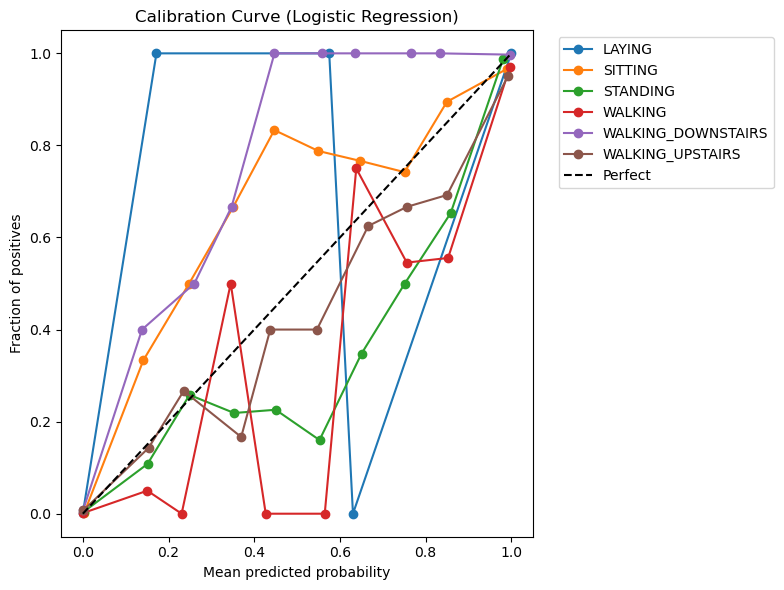

Brier score (macro avg): 0.015396691481472352
LAYING                0.001061
WALKING               0.010308
WALKING_DOWNSTAIRS    0.010752
WALKING_UPSTAIRS      0.018951
STANDING              0.025239
SITTING               0.026068
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import label_binarize

if not hasattr(lr_model, "predict_proba"):
    print("Model does not support predict_proba for calibration.")
else:
    y_proba = lr_model.predict_proba(X_test)
    class_labels = list(le.classes_)
    class_ids = list(range(len(class_labels)))

    y_test_bin = label_binarize(y_test, classes=class_ids)

    brier_per_class = {}
    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(class_labels):
        brier_per_class[cls] = brier_score_loss(y_test_bin[:, i], y_proba[:, i])
        prob_true, prob_pred = calibration_curve(
            y_test_bin[:, i], y_proba[:, i], n_bins=10
        )
        plt.plot(prob_pred, prob_true, marker="o", label=str(cls))

    plt.plot([0, 1], [0, 1], "k--", label="Perfect")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration Curve (Logistic Regression)")
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    brier_macro = float(np.mean(list(brier_per_class.values())))
    print("Brier score (macro avg):", brier_macro)
    print(pd.Series(brier_per_class).sort_values())

# 6. Đóng gói

In [77]:
import joblib

# Lưu lại StandardScaler
joblib.dump(scaler, 'scaler.pkl')

# Lưu lại bộ chọn đặc trưng (SelectFromModel)
joblib.dump(selector, 'selector.pkl')

# Lưu lại mô hình Logistic Regression
joblib.dump(lr_model, 'lr_model.pkl')

['lr_model.pkl']